<a href="https://colab.research.google.com/github/beatriz477/ciencia-de-dados-iesb/blob/main/trabalho_conclus%C3%A3o_de_semestre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Este trabalho utiliza dados do Cartão de Pagamento do Governo Federal (CPGF), refrentes ao primero trimestre de 2026. O obvetivo é analisar padrões de gastos, orgãos responsáveis, fornecedores e distribuição das transações.





In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
plt.style.use("default")

In [10]:
df = pd.read_csv("/content/2026_Q1_CPGF_consolidado.csv", encoding="latin-1", sep=";", on_bad_lines="skip")

In [11]:
display(df.head())

,CÓDIGO ÓRGÃO SUPERIOR,NOME ÓRGÃO SUPERIOR,CÓDIGO ÓRGÃO,NOME ÓRGÃO,CÓDIGO UNIDADE GESTORA,NOME UNIDADE GESTORA,ANO EXTRATO,MÊS EXTRATO,CPF PORTADOR,NOME PORTADOR,CNPJ OU CPF FAVORECIDO,NOME FAVORECIDO,TRANSAÇÃO,DATA TRANSAÇÃO,VALOR TRANSAÇÃO
0,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,1,***.195.852-**,JOSE UELISSON ALVES LEITE,43594727000157,VINIL DECOR MOLDURARIA DECORACAO E COMERICO LTDA,COMPRA A/V - R$ - APRES,05/12/2025,"91,86"
1,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,1,***.212.021-**,SYLVIO EDGARD DE CASTRO,72649361000174,HBL CARIMBOS E PLACAS INDUSTRIA E COMERCIO LTDA,COMPRA A/V - R$ - APRES,19/12/2025,"1435,20"
2,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,1,***.195.852-**,JOSE UELISSON ALVES LEITE,5705694000186,J D COMERCIO E IMPORTACAO LTDA,COMPRA A/V - R$ - APRES,05/12/2025,"336,70"
3,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,1,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,55159876000177,AUDIOPRO COMERCIO DE PRODUTOS DE AUDIO E VIDEO...,COMPRA A/V - R$ - APRES,19/12/2025,"312,00"
4,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,1,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,55159876000177,AUDIOPRO COMERCIO DE PRODUTOS DE AUDIO E VIDEO...,COMPRA A/V - R$ - APRES,16/12/2025,"805,00"


#### Como os valores das transações estão distribuídos?

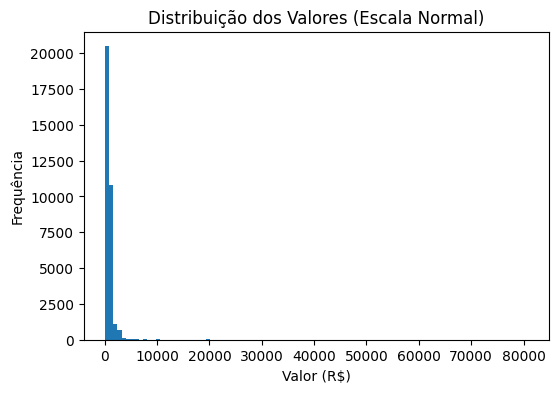

count    33568.000000
mean       731.300246
std       1379.843511
min          0.260000
25%        152.827500
50%        480.000000
75%       1000.000000
max      80766.400000
Name: VALOR TRANSAÇÃO, dtype: float64
Mediana: 480.0


In [12]:
df["VALOR TRANSAÇÃO"] = (df["VALOR TRANSAÇÃO"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float))

df["DATA TRANSAÇÃO"] = pd.to_datetime(df["DATA TRANSAÇÃO"],dayfirst=True)

plt.figure(figsize=(6,4))
plt.hist(df["VALOR TRANSAÇÃO"],bins=100)
plt.title("Distribuição dos Valores (Escala Normal)")
plt.xlabel("Valor (R$)")
plt.ylabel("Frequência")
plt.show()

print(df["VALOR TRANSAÇÃO"].describe())
print("Mediana:", df["VALOR TRANSAÇÃO"].median())

### Compras ou saques são mais frequentes?

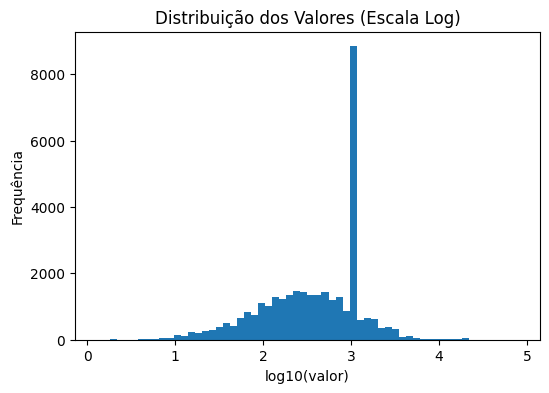

count    33568.000000
mean       731.300246
std       1379.843511
min          0.260000
25%        152.827500
50%        480.000000
75%       1000.000000
max      80766.400000
Name: VALOR TRANSAÇÃO, dtype: float64
Mediana: 480.0


In [13]:
plt.figure(figsize=(6,4))
plt.hist(np.log10(df["VALOR TRANSAÇÃO"] + 1),bins=60)
plt.title("Distribuição dos Valores (Escala Log)")
plt.xlabel("log10(valor)")
plt.ylabel("Frequência")
plt.show()

print(df["VALOR TRANSAÇÃO"].describe())
print("Mediana:", df["VALOR TRANSAÇÃO"].median())

In [14]:
# Distribuição dos valores das transações do CPGF.
# Observa-se forte assimetria à direita, com predominância de gastos de pequeno valor e poucos gastos elevados.

### Compras ou saques são mais frequentes?

TRANSAÇÃO
COMPRA A/V - R$ - APRES               64.457221
Informações protegidas por sigilo     23.617731
SAQUE CASH/ATM BB                     10.158484
COMPRA A/V - INT$ - APRES              1.304814
SAQUE - INT$ - APRES                   0.455791
SAQUE MANUAL-CARTOES BB NA AGENCIA     0.005958
Name: proportion, dtype: float64


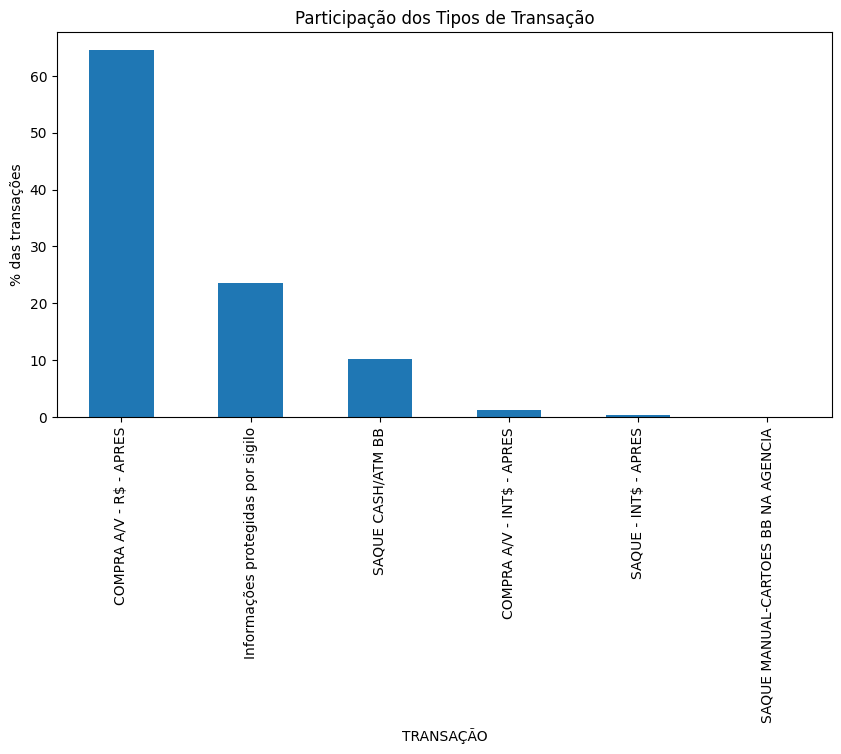

In [15]:
tipos = (df["TRANSAÇÃO"].value_counts(normalize=True).mul(100).sort_values(ascending=False))
print(tipos)
plt.figure(figsize=(10,5))
tipos.plot(kind="bar")
plt.title("Participação dos Tipos de Transação")
plt.ylabel("% das transações")
plt.show()

In [16]:
# Participação percentual dos tipos de transação. As compras representam a maioria das operações registradas.

### Quais órgãos apresentam os maiores gastos?

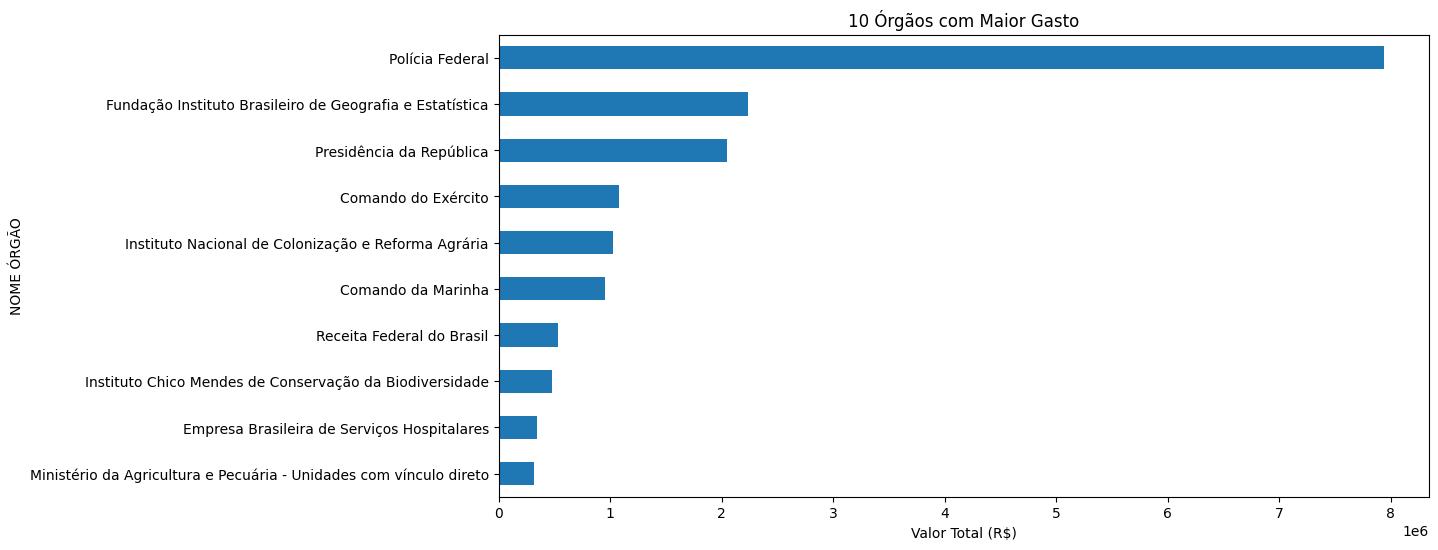

NOME ÓRGÃO
Polícia Federal                                                       7943032.88
Fundação Instituto Brasileiro de Geografia e Estatística              2238410.86
Presidência da República                                              2047237.43
Comando do Exército                                                   1078589.17
Instituto Nacional de Colonização e Reforma Agrária                   1025778.15
Comando da Marinha                                                     952044.90
Receita Federal do Brasil                                              535197.22
Instituto Chico Mendes de Conservação da Biodiversidade                481019.39
Empresa Brasileira de Serviços Hospitalares                            343269.82
Ministério da Agricultura e Pecuária - Unidades com vínculo direto     319171.37
Name: VALOR TRANSAÇÃO, dtype: float64


In [17]:
orgaos = (df.groupby("NOME ÓRGÃO")["VALOR TRANSAÇÃO"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(12,6))
orgaos.sort_values().plot(kind="barh")
plt.title("10 Órgãos com Maior Gasto")
plt.xlabel("Valor Total (R$)")
plt.show()
print(orgaos)

In [18]:
# Ranking dos dez órgãos com maior volume de gastos. Observa-se elevada concentração dos recursos em poucos órgãos.

### Como os gastos variam ao longo dos meses?

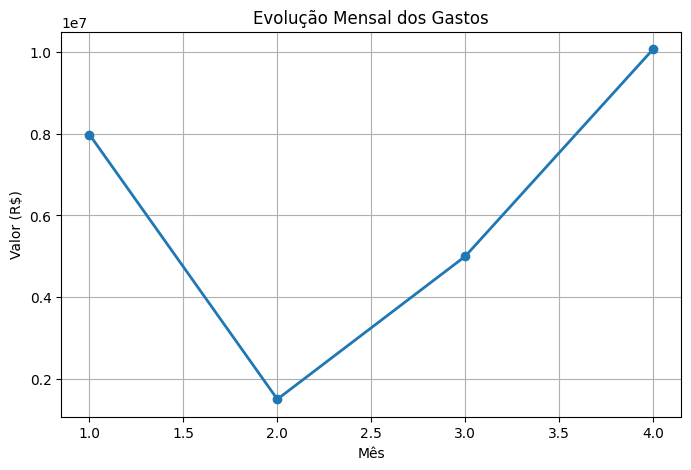

In [19]:
mensal = (df.groupby("MÊS EXTRATO")["VALOR TRANSAÇÃO"].sum())
plt.figure(figsize=(8,5))
mensal.plot(marker="o",linewidth=2)
plt.title("Evolução Mensal dos Gastos")
plt.ylabel("Valor (R$)")
plt.xlabel("Mês")
plt.grid(True)
plt.show()

In [20]:
# Evolução dos gastos por mês do extrato. O período apresenta oscilações relevantes entre janeiro e abril.

### Quais ministérios concentram a maior parte dos gastos?

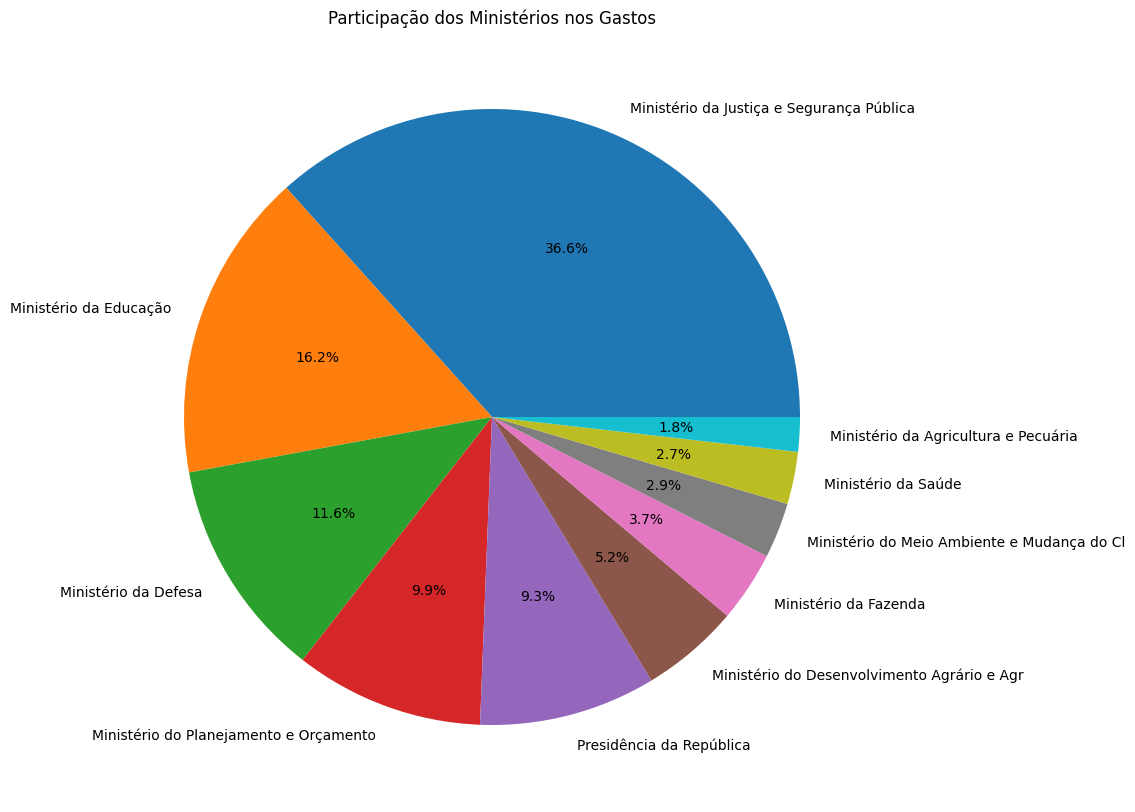

In [21]:
ministerios = (df.groupby("NOME ÓRGÃO SUPERIOR")["VALOR TRANSAÇÃO"].sum().sort_values(ascending=False))
top10 = ministerios.head(10)
plt.figure(figsize=(10,10))
plt.pie(top10,labels=top10.index,autopct="%1.1f%%")
plt.title("Participação dos Ministérios nos Gastos")
plt.show()

In [22]:
# Participação percentual dos principais ministérios. O Ministério da Justiça e Segurança Pública apresenta a maior parcela dos gastos.

### Quais fornecedores receberam os maiores valores?

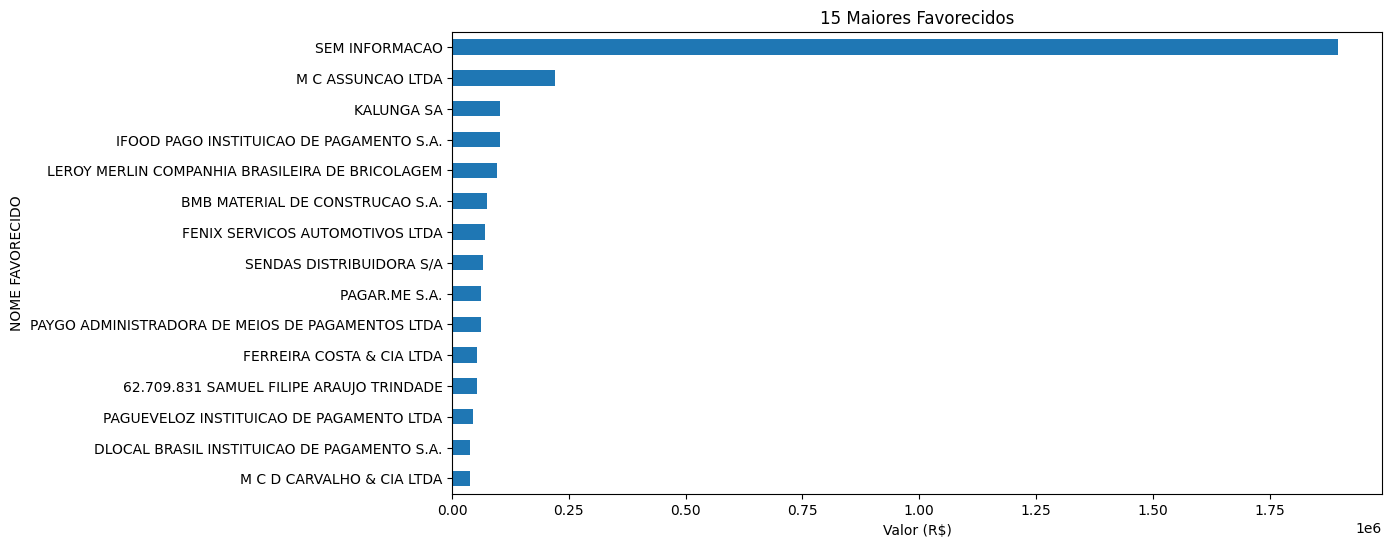

NOME FAVORECIDO
SEM INFORMACAO                                      1896284.88
M C ASSUNCAO LTDA                                    220800.00
KALUNGA SA                                           103272.90
IFOOD PAGO INSTITUICAO DE PAGAMENTO S.A.             102149.56
LEROY MERLIN COMPANHIA BRASILEIRA DE BRICOLAGEM       96889.21
BMB MATERIAL DE CONSTRUCAO S.A.                       74751.34
FENIX SERVICOS AUTOMOTIVOS LTDA                       69847.00
SENDAS DISTRIBUIDORA S/A                              66278.96
PAGAR.ME S.A.                                         61014.38
PAYGO ADMINISTRADORA DE MEIOS DE PAGAMENTOS LTDA      60876.71
FERREIRA COSTA & CIA LTDA                             53713.01
62.709.831 SAMUEL FILIPE ARAUJO TRINDADE              52343.80
PAGUEVELOZ INSTITUICAO DE PAGAMENTO LTDA              44597.13
DLOCAL BRASIL INSTITUICAO DE PAGAMENTO S.A.           37447.08
M C D CARVALHO & CIA LTDA                             37414.00
Name: VALOR TRANSAÇÃO, dtype: float64


In [23]:
compras = df[df["TRANSAÇÃO"].str.contains("COMPRA", case=False, na=False)]
fornecedores = (compras.groupby("NOME FAVORECIDO")["VALOR TRANSAÇÃO"].sum().sort_values(ascending=False).head(15))
plt.figure(figsize=(12,6))
fornecedores.sort_values().plot(kind="barh")
plt.title("15 Maiores Favorecidos")
plt.xlabel("Valor (R$)")
plt.show()
print(fornecedores)

In [24]:
# Principais fornecedores beneficiados pelas compras realizadas via CPGF.

### Qual é o valor médio das transações por tipo?

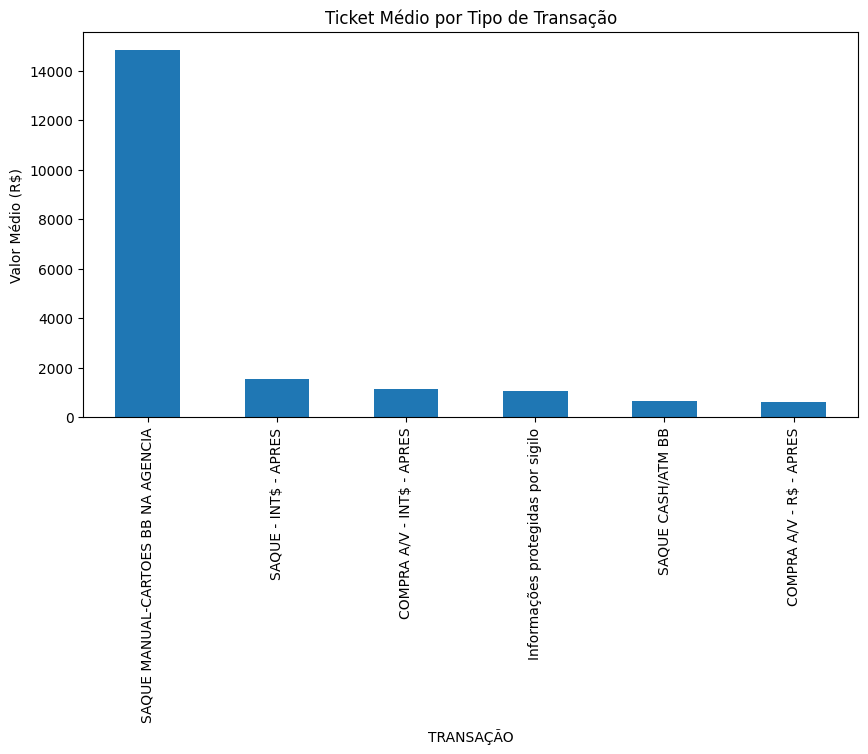

TRANSAÇÃO
SAQUE MANUAL-CARTOES BB NA AGENCIA    14817.500000
SAQUE - INT$ - APRES                   1522.667059
COMPRA A/V - INT$ - APRES              1147.537420
Informações protegidas por sigilo      1072.497979
SAQUE CASH/ATM BB                       637.691202
COMPRA A/V - R$ - APRES                 605.711107
Name: VALOR TRANSAÇÃO, dtype: float64


In [25]:
ticket = (df.groupby("TRANSAÇÃO")["VALOR TRANSAÇÃO"].mean().sort_values(ascending=False))
plt.figure(figsize=(10,5))
ticket.plot(kind="bar")
plt.title("Ticket Médio por Tipo de Transação")
plt.ylabel("Valor Médio (R$)")
plt.show()
print(ticket)


In [26]:
# Valor médio das transações por modalidade.

### Existem transações com valores muito acima do padrão?

Limite: 2270.75875
Quantidade: 1287


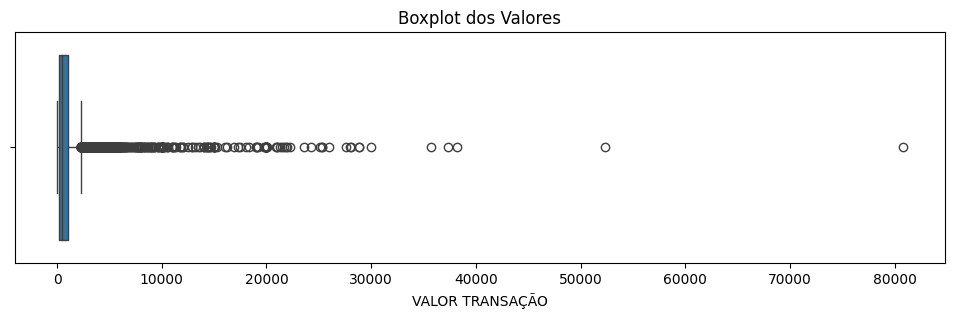

,NOME ÓRGÃO,NOME FAVORECIDO,VALOR TRANSAÇÃO
26780,Polícia Federal,SEM INFORMACAO,80766.40
2895,Superintendência do Desenvolvimento da Amazônia,62.709.831 SAMUEL FILIPE ARAUJO TRINDADE,52343.80
15328,Polícia Federal,SEM INFORMACAO,38201.10
604,Comando da Aeronáutica,SEM INFORMACAO,37353.84
33445,Presidência da República,Sigiloso,35742.00
9523,Presidência da República,Sigiloso,30000.00
26668,Polícia Federal,DLOCAL BRASIL INSTITUICAO DE PAGAMENTO S.A.,28828.08
609,Comando da Aeronáutica,SEM INFORMACAO,28799.07
19131,Presidência da República,Sigiloso,28079.63
19106,Presidência da República,Sigiloso,28000.00


In [27]:
Q1 = df["VALOR TRANSAÇÃO"].quantile(0.25)
Q3 = df["VALOR TRANSAÇÃO"].quantile(0.75)
IQR = Q3 - Q1
limite = Q3 + 1.5*IQR
outliers = df[df["VALOR TRANSAÇÃO"] > limite]
print("Limite:", limite)
print("Quantidade:", len(outliers))
plt.figure(figsize=(12,3))
sns.boxplot(x=df["VALOR TRANSAÇÃO"])
plt.title("Boxplot dos Valores")
plt.show()

outliers.nlargest(10,"VALOR TRANSAÇÃO")[["NOME ÓRGÃO","NOME FAVORECIDO","VALOR TRANSAÇÃO"]]

In [28]:
# Identificação de valores extremos pelo método do intervalo interquartil.

### Em quais dias da semana ocorrem mais transações?

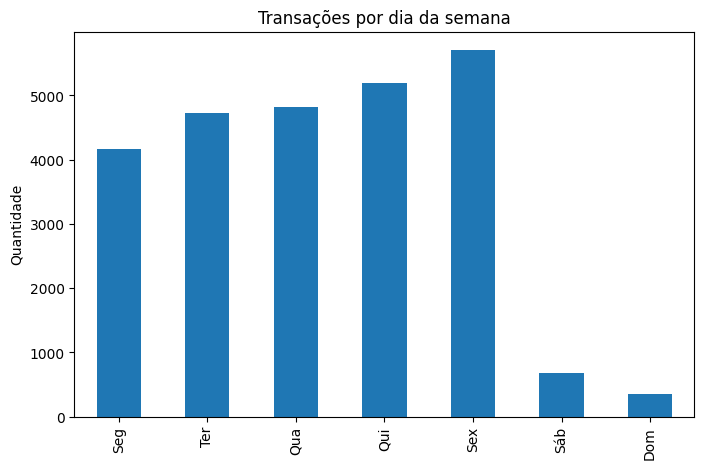

In [29]:
dias = {0:"Seg", 1:"Ter", 2:"Qua",3:"Qui",4:"Sex",5:"Sáb",6:"Dom"}
df["DIA_SEMANA"] = (df["DATA TRANSAÇÃO"].dt.dayofweek)

freq = (df["DIA_SEMANA"].value_counts().sort_index())
freq.index = [dias[d] for d in freq.index]

plt.figure(figsize=(8,5))
freq.plot(kind="bar")
plt.title("Transações por dia da semana")
plt.ylabel("Quantidade")
plt.show()

In [30]:
# Distribuição das transações ao longo da semana. A concentração ocorre principalmente em dias úteis.

### Os gastos estão concentrados em poucas transações?

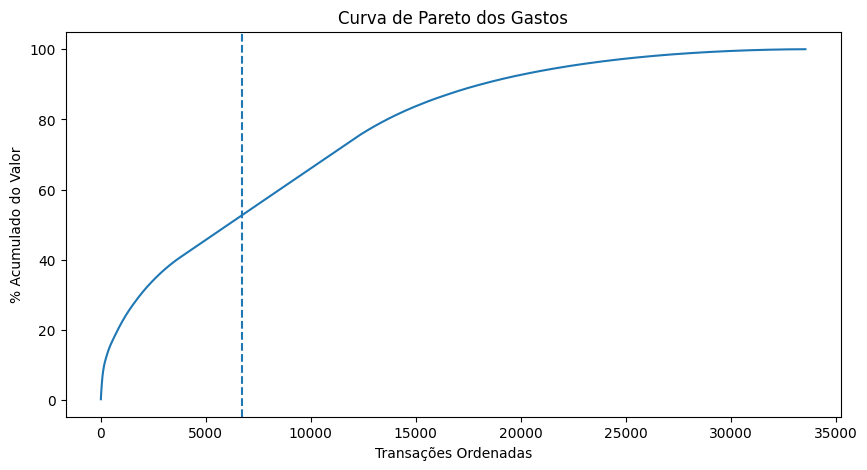

52.68207376094162


In [31]:
valores = np.sort(df["VALOR TRANSAÇÃO"])[::-1]
acumulado = np.cumsum(valores)
acumulado = acumulado/acumulado[-1]*100

plt.figure(figsize=(10,5))
plt.plot(acumulado)
plt.axvline(len(valores)*0.2,linestyle="--")
plt.title("Curva de Pareto dos Gastos")
plt.xlabel("Transações Ordenadas")
plt.ylabel("% Acumulado do Valor")
plt.show()


top20 = int(len(valores)*0.2)
print(acumulado[top20-1])

In [32]:
# Curva de Pareto dos valores transacionados. Os maiores gastos concentram parcela significativa do total movimentado.

###### A análise mostrou que os gastos do CPGF apresentam forte concentração em poucos órgãos e fornecedores. A maioria das transações possui valores relativamente baixos, mas um pequeno grupo de operações representa parcela significativa do total movimentado. Também foi possível identificar padrões temporais e diferenças entre ministérios quanto ao volume e valor médio dos gastos.